# Full-Fidelity Resolved-System Review Notebook

Interactive diagnostic notebook for `full_fidelity_binary_iterative_review.yaml`. Run cells one at a time to inspect the resolved truth/data and inference/reference systems before launching any larger campaign.

This notebook does not run a production campaign or optimization.


## 0. Setup and configuration

Set toggles here. The path resolver supports launching from the repository root or from `examples/notebooks`.


In [1]:
import os
import sys
import tempfile
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for q in (p, *p.parents):
        if (q / "pyproject.toml").exists() or (q / ".git").exists():
            return q
    return p

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "dluxshera-matplotlib"))
REPO_ROOT = find_repo_root()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

CONFIG_PATH = REPO_ROOT / "examples/recipes/full_fidelity_algorithm_campaign_template/full_fidelity_binary_iterative_review.yaml"
OUTPUT_ROOT = REPO_ROOT / "Results/full_fidelity_resolved_system_review"
RUN_LABEL = "interactive_review"
WRITE_ARTIFACTS = True
FAST_RENDER = True
ENABLE_NOISE_AUDIT = True

print("repo root:", REPO_ROOT)
print("PYTHONPATH has src:", str(SRC) in sys.path)
print("config path:", CONFIG_PATH)
print("output root:", OUTPUT_ROOT / RUN_LABEL)


repo root: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox
PYTHONPATH has src: True
config path: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/examples/recipes/full_fidelity_algorithm_campaign_template/full_fidelity_binary_iterative_review.yaml
output root: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/full_fidelity_resolved_system_review/interactive_review


### Plotting backend policy

For interactive pan/zoom plots in Jupyter Lab, install `ipympl` and set `PLOT_BACKEND = "widget"`. If `ipympl` is unavailable, use `PLOT_BACKEND = "inline"` for reliable static plots. Use `PLOT_BACKEND = "agg"` only for headless artifact generation.


In [2]:
# Plotting backend policy
#
# Use "widget" for interactive pan/zoom in Jupyter Lab when ipympl is installed.
# Use "inline" for robust static plots in any notebook.
# Use "auto" to prefer widget and fall back to inline.
# Do not use "agg" in this review notebook; it disables inline display.
PLOT_BACKEND = "inline"  # options: "auto", "widget", "inline", "notebook"

import importlib.util
import sys


def configure_notebook_matplotlib_backend(mode="auto"):
    """Configure Matplotlib for interactive notebook review."""
    try:
        ip = get_ipython()
    except NameError:
        ip = None

    if mode == "agg":
        raise ValueError("PLOT_BACKEND='agg' disables notebook display; use inline or widget here.")

    if ip is None:
        # Not running in IPython/Jupyter. Leave backend alone.
        return "unchanged_non_ipython"

    if mode in {"auto", "widget"}:
        if importlib.util.find_spec("ipympl") is not None:
            active = "widget"
            ip.run_line_magic("matplotlib", active)
            _switch_existing_pyplot_backend(active)
            return active
        if mode == "widget":
            print("ipympl is not installed; falling back to inline backend.")

    if mode == "notebook":
        active = "notebook"
        ip.run_line_magic("matplotlib", active)
        _switch_existing_pyplot_backend(active)
        return active

    active = "inline"
    ip.run_line_magic("matplotlib", active)
    _switch_existing_pyplot_backend(active)
    return active


def _switch_existing_pyplot_backend(mode):
    """Repair pyplot if a prior cell or stale imported helper switched to Agg."""
    if "matplotlib.pyplot" not in sys.modules:
        return
    import matplotlib.pyplot as plt

    backend = {
        "inline": "module://matplotlib_inline.backend_inline",
        "widget": "module://ipympl.backend_nbagg",
        "notebook": "nbAgg",
    }.get(mode)
    if backend is None:
        return
    try:
        plt.switch_backend(backend)
        plt.ion()
    except Exception as exc:
        print(f"Could not switch existing pyplot backend to {mode}: {exc}")


ACTIVE_MATPLOTLIB_BACKEND = configure_notebook_matplotlib_backend(PLOT_BACKEND)
print(f"Matplotlib notebook backend: {ACTIVE_MATPLOTLIB_BACKEND}")


Matplotlib notebook backend: inline


In [3]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.ion()

from dluxshera.utils import full_fidelity_review as review

cfg = review.load_smoke_config(CONFIG_PATH)
exp = cfg["experiment"]
outdir = OUTPUT_ROOT / RUN_LABEL
outdir.mkdir(parents=True, exist_ok=True)

print("schema_version:", exp.get("schema_version"))
print("run_name:", exp.get("run_name"))
print("source_kind:", exp.get("source_kind"))
print("target:", exp.get("target"))
print("system_preset:", exp.get("system_preset"))
print("output directory:", outdir)


schema_version: full_fidelity_binary_iterative_review.v1
run_name: full_fidelity_binary_iterative_review
source_kind: binary_target
target: ALPHA_CEN
system_preset: SHERA_FLIGHT_3P_CONV
output directory: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/full_fidelity_resolved_system_review/interactive_review


In [4]:
import matplotlib

probe_fig = plt.figure(figsize=(1, 1))
print("Matplotlib backend:", matplotlib.get_backend())
print("Figure canvas:", type(probe_fig.canvas).__module__, type(probe_fig.canvas).__name__)
print("Interactive mode:", plt.isinteractive())
plt.close(probe_fig)


Matplotlib backend: module://matplotlib_inline.backend_inline
Figure canvas: matplotlib.backends.backend_agg FigureCanvasAgg
Interactive mode: True


## 0a. Config contract registry

Display registry-backed enum/option validation for the active config.


In [5]:
from dluxshera.utils.full_fidelity_config_schema import registry_entry_for_path, iter_string_fields, validate_config_contract

contract = validate_config_contract(cfg, config_tier='review', strict=False)
print('contract findings:', len(contract['findings']))
for finding in contract['findings']:
    print(f"{finding['severity']} {finding['field_path']} {finding['code']}: {finding['message']}")

rows = []
for path, value in iter_string_fields(cfg):
    pattern, entry = registry_entry_for_path(path)
    rows.append({
        'field_path': path,
        'value': value,
        'registry_pattern': pattern,
        'valid_values': ', '.join((entry or {}).get('valid_values', {}).keys()),
        'implemented_status': (entry or {}).get('implemented_status'),
    })
display(pd.DataFrame(rows))


contract findings: 0


,field_path,value,registry_pattern,valid_values,implemented_status
0,experiment.kind,full_fidelity_binary_iterative_review,experiment.kind,"full_fidelity_binary_iterative_review, full_fi...",implemented
1,experiment.schema_version,full_fidelity_binary_iterative_review.v1,experiment.schema_version,,implemented
2,experiment.run_name,full_fidelity_binary_iterative_review,experiment.run_name,,implemented
3,experiment.source_kind,binary_target,experiment.source_kind,"binary_target, binary, alpha_cen",implemented
4,experiment.target,ALPHA_CEN,experiment.target,,implemented
...,...,...,...,...,...
72,experiment.prior_draws.sigmas.optics.plate_sca...,fractional,experiment.prior_draws.sigmas.*.kind,"absolute, fractional, ppm, percent",implemented
73,experiment.prior_draws.sigmas.optics.primary.z...,absolute,experiment.prior_draws.sigmas.*.kind,"absolute, fractional, ppm, percent",implemented
74,experiment.prior_draws.sigmas.optics.primary.z...,nm,experiment.prior_draws.sigmas.*.unit,,implemented
75,experiment.prior_draws.sigmas.optics.secondary...,absolute,experiment.prior_draws.sigmas.*.kind,"absolute, fractional, ppm, percent",implemented


## 1. Translate smoke config and build model split

This uses the smoke wrapper's private translator by file-path import, then builds the package `CampaignModelSplit` without launching subblock inference.


In [6]:
ctx = review.build_model_split_from_smoke(cfg, outdir, run_label=RUN_LABEL, write_artifacts=WRITE_ARTIFACTS)
translated = ctx["translated_config"]
base_system = ctx["base_system_cfg"]
truth_system = ctx["truth_system_cfg"]
inference_system = ctx["inference_system_cfg"]
split = ctx["model_split"]
ACTIVE_MATPLOTLIB_BACKEND = configure_notebook_matplotlib_backend(PLOT_BACKEND)

print("translated kind:", translated["experiment"].get("kind"))
print("truth hash:", split.truth_config_hash)
print("inference hash:", split.inference_config_hash)
print("matched:", split.truth_config_hash == split.inference_config_hash)
print("model split components:")
print(json.dumps(split.enabled_components, indent=2))


translated kind: observation_bias_campaign
truth hash: e783dfbff8fad57b3e6f342478ef715d4129968f4dc146d2cc5cd01857049620
inference hash: d923a846989d3641fcbc3cde819b2ef9fd7ee81fe4cbed4058f7d549c2720edc
matched: False
model split components:
{
  "spectral_model": {
    "enabled": true,
    "truth_label": null,
    "inference_label": null,
    "matched": false,
    "artifact_root": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/full_fidelity_resolved_system_review/interactive_review/model_split/spectral"
  },
  "high_order_wfe": {
    "enabled": true,
    "truth_label": "high_order_truth",
    "inference_label": "knowledge_error",
    "matched": false,
    "artifact_root": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/full_fidelity_resolved_system_review/interactive_review/model_split/high_order_wfe",
    "warnings": []
  },
  "scalar_reference_offsets": {
    "enabled": false,
    "n_offsets": 0
  },
  "trajectory_smear": {
    "enabled": true,
    "mode": "met

In [7]:
for role, system in [("base", base_system), ("truth", truth_system), ("inference", inference_system)]:
    s = review.summarize_source_config(system)
    print(f"{role} source wavelength_m / bandwidth_m / n_lambda:", s["wavelength_m"], s["bandwidth_m"], s["n_lambda"])
    print("  explicit wavelengths_m / weights / component_weights:", s["has_wavelengths_m"], s["has_weights"], s["has_component_weights"])

print("\nOriginal review config excerpt:")
print(json.dumps({k: exp.get(k) for k in ["spectral_model", "high_order_wfe", "subblocks", "iterative"]}, indent=2)[:5000])
print("\nTranslated observation-bias config excerpt:")
print(json.dumps(translated["experiment"], indent=2)[:5000])


base source wavelength_m / bandwidth_m / n_lambda: 5.5e-07 4.1e-08 3
  explicit wavelengths_m / weights / component_weights: False False False
truth source wavelength_m / bandwidth_m / n_lambda: 6e-07 5e-07 31
  explicit wavelengths_m / weights / component_weights: True False True
inference source wavelength_m / bandwidth_m / n_lambda: 6e-07 5e-07 7
  explicit wavelengths_m / weights / component_weights: True False True

Original review config excerpt:
{
  "spectral_model": {
    "enabled": true,
    "preserve_flux_parameters": true,
    "photometry_mode": "preserve_detected_flux_parameters",
    "source_seds": {
      "mode": "target",
      "generic_binary_fallback": "alpha_cen"
    },
    "truth": {
      "label": "truth_review_alpha_cen",
      "mode": "effective_source_spectrum",
      "n_lambda": 31,
      "wavelength_min_nm": 350.0,
      "wavelength_max_nm": 850.0,
      "components": {
        "detector_qe": {
          "enabled": true,
          "path": "data/detector_qe/LTN4

## 2. Spectral model review

Answers: actual truth/reference wavelength grids, `fast` clamp, inference wavelength override, component SED/weight differences, response-curve availability, and flux-factor provenance.


In [8]:
spectral_summary = review.summarize_spectral_deck(split)
spectral_tables = review.spectral_review_tables(base_system, truth_system, inference_system)
truth_spec = pd.DataFrame(spectral_tables["truth"])
inf_spec = pd.DataFrame(spectral_tables["inference"])
responses = review.response_curve_review(translated["experiment"].get("spectral_model"))

print(json.dumps({k: v for k, v in spectral_summary.items() if k != "provenance"}, indent=2, default=str))
print("truth rows:", len(truth_spec), "inference rows:", len(inf_spec))
print("detector QE enabled/available:", responses["detector_qe"]["enabled"], responses["detector_qe"]["available"])
print("M2 filter enabled/available:", responses["m2_filter_response"]["enabled"], responses["m2_filter_response"]["available"])

if WRITE_ARTIFACTS:
    review.write_spectral_review_csv(outdir / "spectral_review_tables.csv", spectral_tables)

display(truth_spec)
display(inf_spec)


{
  "truth": {
    "kind": "binary_target",
    "target": "ALPHA_CEN",
    "wavelength_m": 6e-07,
    "bandwidth_m": 5e-07,
    "n_lambda": 31,
    "has_wavelengths_m": true,
    "has_weights": false,
    "has_component_weights": true,
    "wavelengths_nm": [
      350.00000000000006,
      366.66666666666674,
      383.33333333333337,
      400.00000000000006,
      416.66666666666674,
      433.3333333333334,
      450.00000000000006,
      466.66666666666674,
      483.3333333333334,
      500.00000000000006,
      516.6666666666667,
      533.3333333333335,
      550.0,
      566.6666666666669,
      583.3333333333334,
      600.0000000000001,
      616.6666666666667,
      633.3333333333335,
      650.0,
      666.6666666666669,
      683.3333333333334,
      700.0000000000001,
      716.6666666666667,
      733.3333333333335,
      750.0,
      766.6666666666669,
      783.3333333333334,
      800.0000000000001,
      816.6666666666667,
      833.3333333333335,
      850.0
    ],

,role,component,index,wavelength_nm,weight
0,truth,primary,0,350.000000,0.000449
1,truth,primary,1,366.666667,0.000540
2,truth,primary,2,383.333333,0.000875
3,truth,primary,3,400.000000,0.001148
4,truth,primary,4,416.666667,0.001386
...,...,...,...,...,...
57,truth,secondary,26,783.333333,0.001736
58,truth,secondary,27,800.000000,0.001161
59,truth,secondary,28,816.666667,0.001400
60,truth,secondary,29,833.333333,0.001251


,role,component,index,wavelength_nm,weight
0,inference,primary,0,350.000000,0.008174
1,inference,primary,1,433.333333,0.029474
2,inference,primary,2,516.666667,0.869611
3,inference,primary,3,600.000000,0.011507
4,inference,primary,4,683.333333,0.044663
5,inference,primary,5,766.666667,0.021968
6,inference,primary,6,850.000000,0.014602
7,inference,secondary,0,350.000000,0.005822
8,inference,secondary,1,433.333333,0.025791
9,inference,secondary,2,516.666667,0.849055


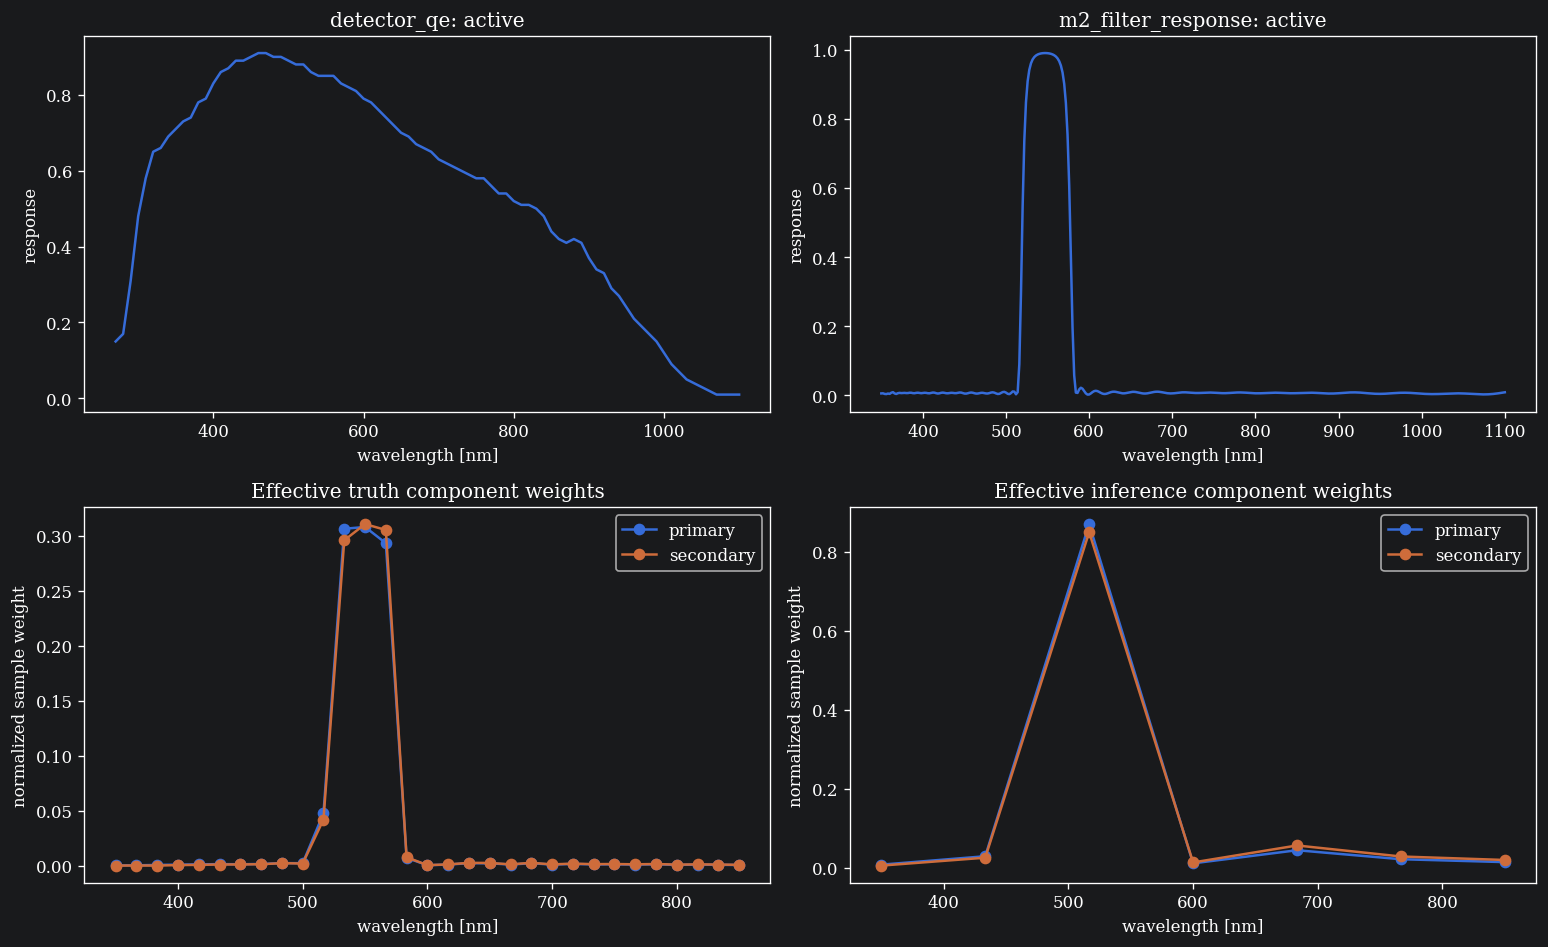

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (label, response) in zip(axes[0], responses.items()):
    if response["available"]:
        ax.plot(response["wavelengths_nm"], response["response"])
    ax.set_title(f"{label}: {'active' if response['enabled'] else 'available but not active'}")
    ax.set_xlabel("wavelength [nm]")
    ax.set_ylabel("response")

for role, df, ax in [("truth", truth_spec, axes[1,0]), ("inference", inf_spec, axes[1,1])]:
    for comp, group in df.groupby("component"):
        ax.plot(group["wavelength_nm"], group["weight"], marker="o", label=comp)
    ax.set_title(f"Effective {role} component weights")
    ax.set_xlabel("wavelength [nm]")
    ax.set_ylabel("normalized sample weight")
    ax.legend()
plt.tight_layout()
plt.show()


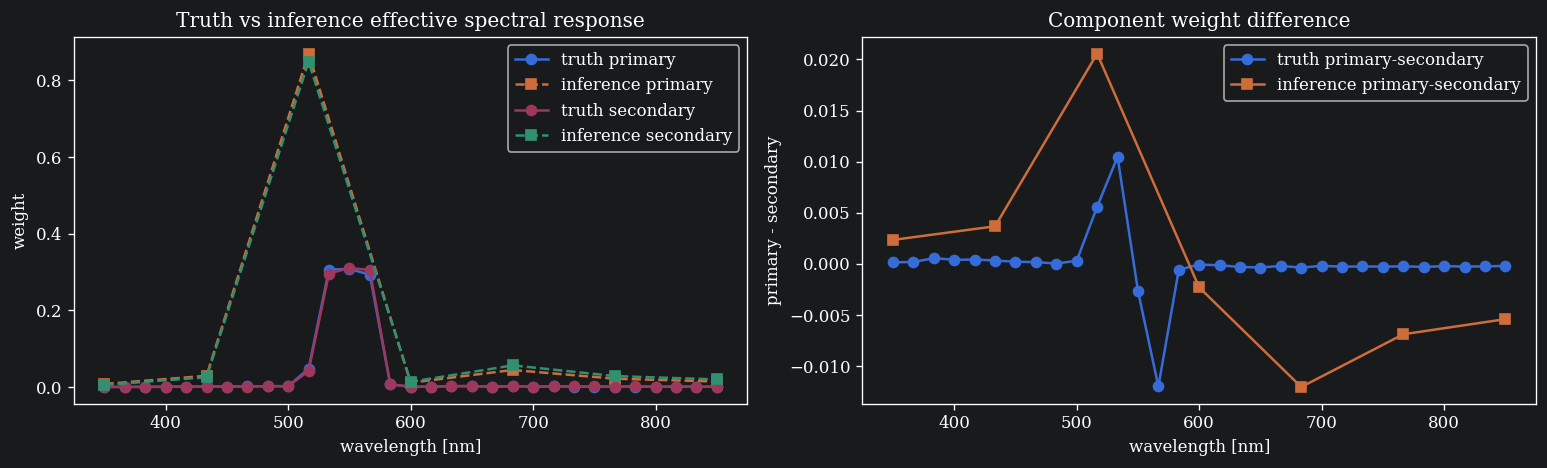

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for comp in sorted(set(truth_spec["component"])):
    t = truth_spec[truth_spec["component"] == comp]
    i = inf_spec[inf_spec["component"] == comp]
    axes[0].plot(t["wavelength_nm"], t["weight"], marker="o", label=f"truth {comp}")
    axes[0].plot(i["wavelength_nm"], i["weight"], marker="s", linestyle="--", label=f"inference {comp}")

if {"primary", "secondary"} <= set(truth_spec["component"]):
    tp = truth_spec[truth_spec["component"] == "primary"].sort_values("wavelength_nm")
    ts = truth_spec[truth_spec["component"] == "secondary"].sort_values("wavelength_nm")
    axes[1].plot(tp["wavelength_nm"], tp["weight"].to_numpy() - ts["weight"].to_numpy(), marker="o", label="truth primary-secondary")
if {"primary", "secondary"} <= set(inf_spec["component"]):
    ip = inf_spec[inf_spec["component"] == "primary"].sort_values("wavelength_nm")
    isec = inf_spec[inf_spec["component"] == "secondary"].sort_values("wavelength_nm")
    axes[1].plot(ip["wavelength_nm"], ip["weight"].to_numpy() - isec["weight"].to_numpy(), marker="s", label="inference primary-secondary")
axes[0].set_title("Truth vs inference effective spectral response")
axes[0].set_xlabel("wavelength [nm]")
axes[0].set_ylabel("weight")
axes[0].legend()
axes[1].set_title("Component weight difference")
axes[1].set_xlabel("wavelength [nm]")
axes[1].set_ylabel("primary - secondary")
axes[1].legend()
plt.tight_layout()
plt.show()


In [11]:
def effective_rows(df):
    rows = []
    for comp, group in df.groupby("component"):
        w = group["weight"].to_numpy(float)
        lam = group["wavelength_nm"].to_numpy(float)
        rows.append({"component": comp, "sum_weights": w.sum(), "effective_wavelength_nm": (w * lam).sum() / w.sum()})
    return pd.DataFrame(rows)

print("Truth effective wavelengths")
display(effective_rows(truth_spec))
print("Inference effective wavelengths")
display(effective_rows(inf_spec))
print("Flux/provenance entries")
print(json.dumps(spectral_summary["provenance"], indent=2, default=str)[:8000])


Truth effective wavelengths


,component,sum_weights,effective_wavelength_nm
0,primary,1.0,550.685882
1,secondary,1.0,552.312541


Inference effective wavelengths


,component,sum_weights,effective_wavelength_nm
0,primary,1.0,531.610338
1,secondary,1.0,538.021629


Flux/provenance entries
{
  "schema_version": "spectral_source_config.v1",
  "truth": {
    "applied_to": "source",
    "role": "truth",
    "source_kind": "binary_target",
    "target": "ALPHA_CEN",
    "spectrum": {
      "source_kind": "binary_target",
      "component_labels": [
        "primary",
        "secondary"
      ],
      "n_lambda": 31,
      "component_spectra": {
        "primary": {
          "spectrum_label": "truth_primary",
          "source_kind": "binary_target",
          "component_labels": [
            "primary"
          ],
          "n_lambda": 31,
          "flux_factor": 4645588498.987997,
          "lambda_eff_nm": 550.685881957448,
          "bandwidth_rms_nm": 33.52079156482448,
          "weights_sum": 1.0,
          "weight_normalization": "sample_sum",
          "wavelength_unit": "m",
          "flux_factor_usage": "diagnostic_provenance_only",
          "log_flux_total_and_contrast": "preserved_detected_post_response_band_integrated",
          "s

## 3. Preserve-flux-parameters review

Verifies that spectral deck patching changes chromatic shape and provenance, not scalar band-integrated flux parameters, when `preserve_flux_parameters: true`.


In [12]:
flux_review = review.preserve_flux_review(base_system, truth_system, inference_system, translated["experiment"].get("spectral_model"))
print(json.dumps(flux_review, indent=2, default=str))
for warning in flux_review["warnings"]:
    print("WARNING:", warning)

for role, system in [("truth", truth_system), ("inference", inference_system)]:
    s = review.summarize_source_config(system)
    print(role, "component row sums:", s["component_weight_sums"])
    assert all(np.isclose(v, 1.0) for v in s["component_weight_sums"]), role


{
  "preserve_flux_parameters": true,
  "base": {
    "log_flux_total": null,
    "contrast": null
  },
  "truth": {
    "log_flux_total": null,
    "contrast": null
  },
  "inference": {
    "log_flux_total": null,
    "contrast": null
  },
  "warnings": [
    "preserve_flux_parameters is configured; consumption should be verified against spectral provenance."
  ]
}
truth component row sums: [1.0, 1.0]
inference component row sums: [1.0000000000000002, 1.0]


## 4. High-order WFE review

This section checks the WFE bookkeeping. The raw PTT-removed OPD map is decomposed into stored low-order Zernike coefficients plus a high-order residual map. The high-order knowledge error is also projected into the high-order residual subspace so that low-order WFE uncertainty is not double-counted. The inference/reference high-order map should equal the truth high-order residual plus the high-order knowledge-error residual.

`npix=16` is smoke-only and should not be used for serious WFE studies. A practical next step is to match the generated high-order map sampling to the resolved pupil sampling (`optics.pupil_npix`) when feasible, or document a downsample/upsample policy.


In [13]:
wfe_summary = review.summarize_wfe_artifacts(split)
print("enabled:", wfe_summary.get("enabled"))
print("warnings:", wfe_summary.get("warnings"))
for mirror, item in wfe_summary.get("mirrors", {}).items():
    print("\n", mirror)
    print(" requested truth RMS:", item["requested_truth_rms_nm"], "high-order residual measured:", item["rms_nm"]["truth_high_order_residual"])
    print(" requested error RMS:", item["requested_knowledge_error_rms_nm"], "residual measured:", item["rms_nm"]["knowledge_error_residual"])
    print(" raw = low-order + residual RMS:", item["rms_nm"]["raw_ptt_removed_truth"], item["rms_nm"]["low_order_reconstruction"], item["rms_nm"]["truth_high_order_residual"])
    print(" inference sum residual RMS:", item["rms_nm"]["inference_sum_residual"])
    print(" stored coefficient index mapping:", item["coefficient_array_index_mapping"])
    if item["warnings"]:
        print(" mirror warnings:", item["warnings"])
    if item["truth_high_order_residual_opd_nm"].shape[0] < int(truth_system["optics"].get("pupil_npix", 0)):
        print("WARNING: WFE npix is much smaller than optics pupil_npix", item["truth_high_order_residual_opd_nm"].shape, truth_system["optics"].get("pupil_npix"))


enabled: True
warnings: []

 primary
 requested truth RMS: 20.0 high-order residual measured: 18.272960864258074
 requested error RMS: 0.1 residual measured: 0.1
 raw = low-order + residual RMS: 20.0 8.130123077376663 18.272960864258074
 inference sum residual RMS: 0.0
 stored coefficient index mapping: {0: {'label': 'Z4', 'noll_index': 4}, 1: {'label': 'Z5', 'noll_index': 5}, 2: {'label': 'Z6', 'noll_index': 6}, 3: {'label': 'Z7', 'noll_index': 7}, 4: {'label': 'Z8', 'noll_index': 8}, 5: {'label': 'Z9', 'noll_index': 9}, 6: {'label': 'Z10', 'noll_index': 10}, 7: {'label': 'Z11', 'noll_index': 11}}

 secondary
 requested truth RMS: 20.0 high-order residual measured: 16.243746749114226
 requested error RMS: 0.1 residual measured: 0.1
 raw = low-order + residual RMS: 20.0 11.667934330919122 16.243746749114226
 inference sum residual RMS: 0.0
 stored coefficient index mapping: {0: {'label': 'Z4', 'noll_index': 4}, 1: {'label': 'Z5', 'noll_index': 5}, 2: {'label': 'Z6', 'noll_index': 6}, 3

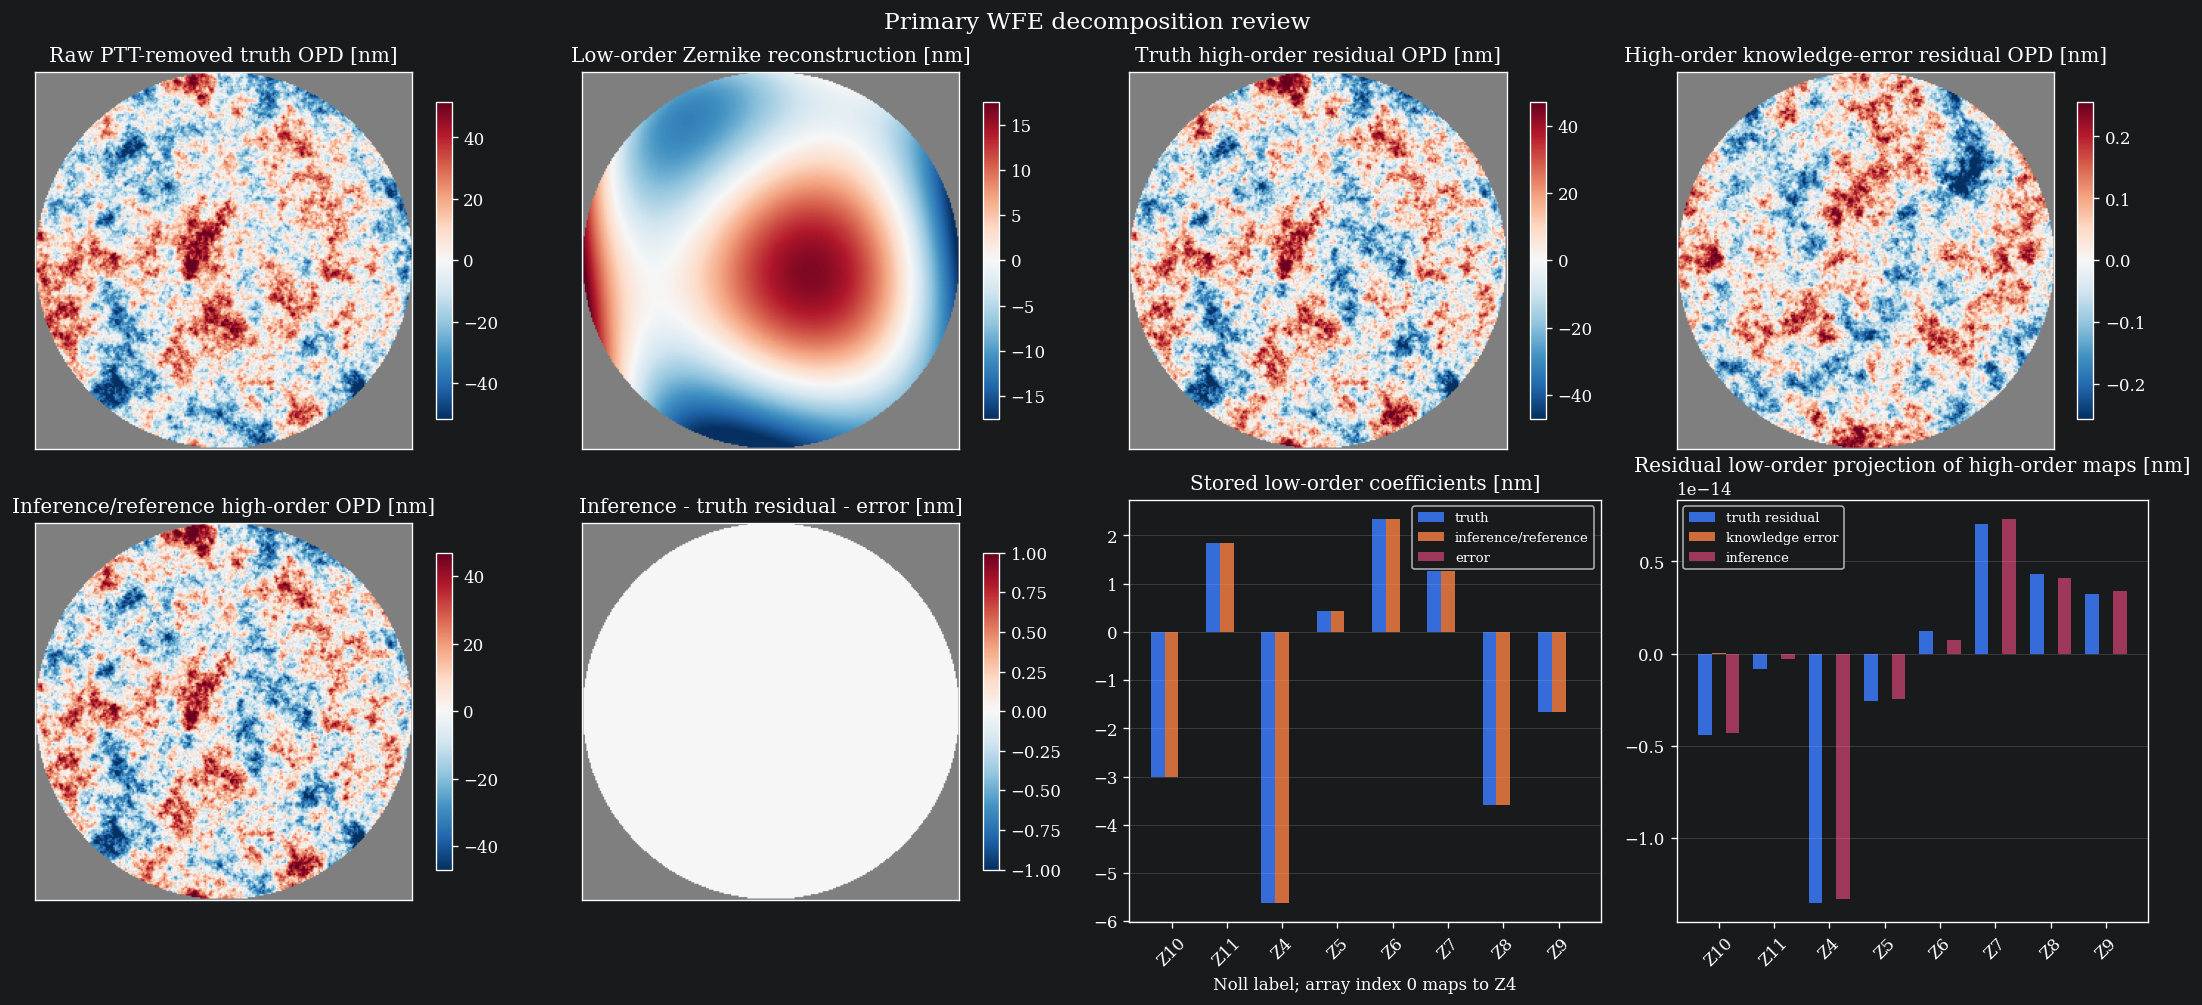

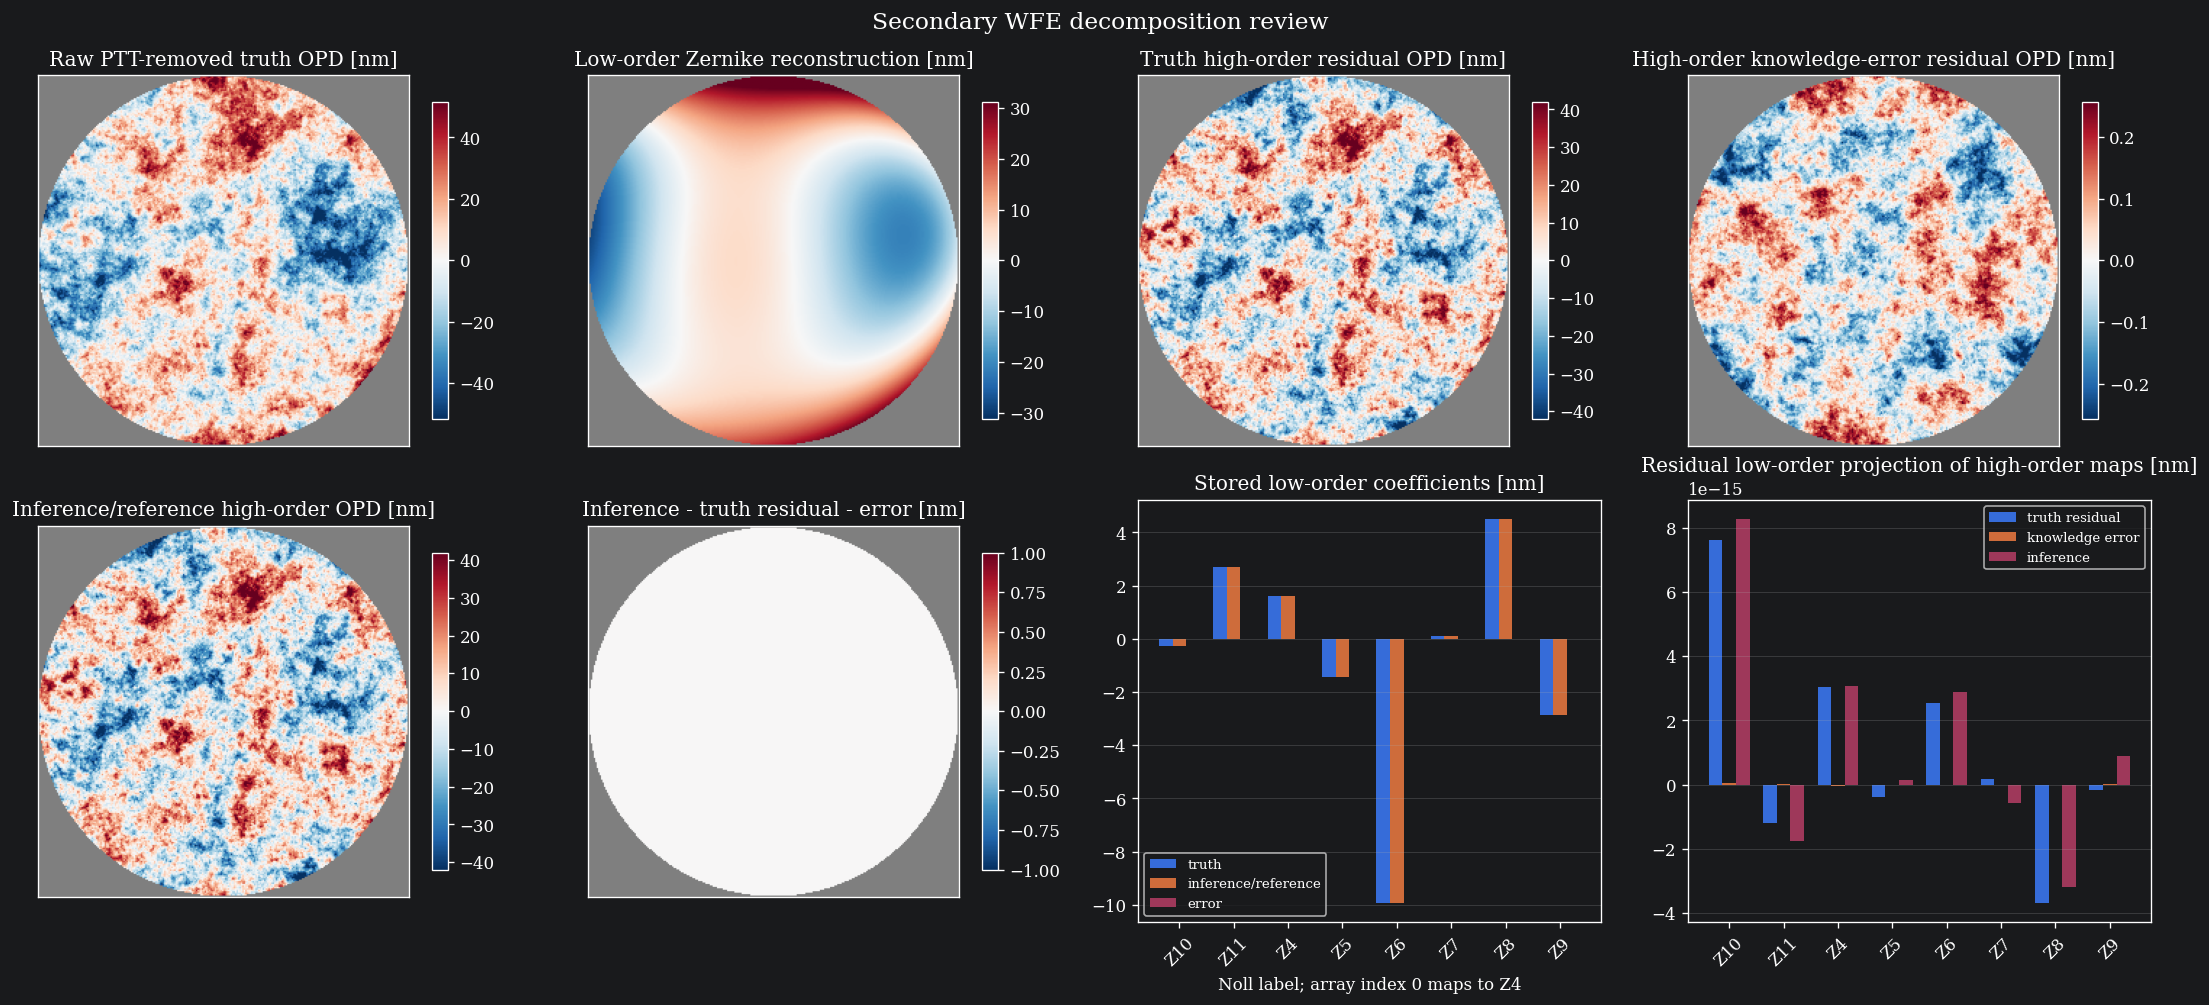

In [14]:
wfe_cmap = review.cmap_with_bad("RdBu_r", bad="0.5")
for mirror, item in wfe_summary.get("mirrors", {}).items():
    title_prefix = mirror.capitalize()
    fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
    fig.suptitle(f"{title_prefix} WFE decomposition review", fontsize=14)
    image_panels = [
        ("Raw PTT-removed truth OPD [nm]", item["raw_ptt_removed_truth_opd_nm"]),
        ("Low-order Zernike reconstruction [nm]", item["low_order_truth_reconstruction_nm"]),
        ("Truth high-order residual OPD [nm]", item["truth_high_order_residual_opd_nm"]),
        ("High-order knowledge-error residual OPD [nm]", item["knowledge_error_high_order_residual_opd_nm"]),
        ("Inference/reference high-order OPD [nm]", item["inference_high_order_opd_nm"]),
        ("Inference - truth residual - error [nm]", item["inference_sum_residual_nm"]),
    ]
    for ax, (title, arr) in zip(axes.flat[:6], image_panels):
        masked = review.masked_for_imshow(arr, item["mask"])
        vmin, vmax = review.symmetric_nan_limits(masked, percentile=99.0)
        im = ax.imshow(masked, origin="lower", cmap=wfe_cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, shrink=0.75)

    labels = list(item["stored_low_order_coefficients_nm"]["truth"].keys())
    x = np.arange(len(labels))
    stored = item["stored_low_order_coefficients_nm"]
    axes.flat[6].bar(x - 0.25, [stored["truth"][k] for k in labels], width=0.25, label="truth")
    axes.flat[6].bar(x, [stored["inference"][k] for k in labels], width=0.25, label="inference/reference")
    axes.flat[6].bar(x + 0.25, [stored["error"][k] for k in labels], width=0.25, label="error")
    axes.flat[6].set_xticks(x, labels, rotation=45)
    axes.flat[6].set_title("Stored low-order coefficients [nm]")
    axes.flat[6].set_xlabel("Noll label; array index 0 maps to Z4")
    axes.flat[6].grid(True, axis="y", alpha=0.25)
    axes.flat[6].legend(fontsize=8)

    projection = item["residual_low_order_projection_nm"]
    axes.flat[7].bar(x - 0.25, [projection["truth_high_order_residual"][k] for k in labels], width=0.25, label="truth residual")
    axes.flat[7].bar(x, [projection["knowledge_error_residual"][k] for k in labels], width=0.25, label="knowledge error")
    axes.flat[7].bar(x + 0.25, [projection["inference_high_order"][k] for k in labels], width=0.25, label="inference")
    axes.flat[7].set_xticks(x, labels, rotation=45)
    axes.flat[7].set_title("Residual low-order projection of high-order maps [nm]")
    axes.flat[7].grid(True, axis="y", alpha=0.25)
    axes.flat[7].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


The residual projection bars are expected to be near zero. Differences at the numerical-noise level do not represent meaningful low-order WFE bias. Meaningful low-order bias should be read from the stored low-order coefficient plot/table.


## 5. Optics and system-preset review


In [15]:
optics_rows = pd.DataFrame(review.optics_diff_table(base_system, truth_system, inference_system))
print("Base optics")
print(json.dumps(review.summarize_optics_config(base_system), indent=2, default=str))
print("Truth optics")
print(json.dumps(review.summarize_optics_config(truth_system), indent=2, default=str))
print("Inference optics")
print(json.dumps(review.summarize_optics_config(inference_system), indent=2, default=str))
display(optics_rows)


Base optics
{
  "preset": "SHERA_FLIGHT_3P_CONV",
  "kind": "three_plane",
  "psf_npix": 256,
  "oversample": 3,
  "pupil_npix": 256,
  "plate_scale_as_per_pix": null,
  "primary_noll_indices": [
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11
  ],
  "secondary_noll_indices": [
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11
  ],
  "high_order_wfe_enabled": false,
  "diffractive_pupil_path": "src/dluxshera/data/pupils/diffractive_pupil.npy",
  "special_keys": [
    "dp_design_wavelength_m",
    "dp_path",
    "pupil_npix"
  ]
}
Truth optics
{
  "preset": "SHERA_FLIGHT_3P_CONV",
  "kind": "three_plane",
  "psf_npix": 256,
  "oversample": 3,
  "pupil_npix": 256,
  "plate_scale_as_per_pix": null,
  "primary_noll_indices": [
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11
  ],
  "secondary_noll_indices": [
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11
  ],
  "high_order_wfe_enabled": true,
  "diffractive_pupil_path": "src/dluxshera/data/pupils/diffract

,config_path,base_value,truth_value,inference_value,status
0,optics.kind,three_plane,three_plane,three_plane,matched
1,optics.psf_npix,256,256,256,matched
2,optics.oversample,3,3,3,matched
3,optics.pupil_npix,256,256,256,matched
4,optics.plate_scale_as_per_pix,None,None,None,matched
5,optics.primary_noll_indices,"[4, 5, 6, 7, 8, 9, 10, 11]","[4, 5, 6, 7, 8, 9, 10, 11]","[4, 5, 6, 7, 8, 9, 10, 11]",matched
6,optics.secondary_noll_indices,"[4, 5, 6, 7, 8, 9, 10, 11]","[4, 5, 6, 7, 8, 9, 10, 11]","[4, 5, 6, 7, 8, 9, 10, 11]",matched
7,optics.high_order_wfe.enabled,None,True,True,matched
8,optics.dp_path,src/dluxshera/data/pupils/diffractive_pupil.npy,src/dluxshera/data/pupils/diffractive_pupil.npy,src/dluxshera/data/pupils/diffractive_pupil.npy,matched


## 6. Detector layer and calibration-map review

Absent maps are reported clearly rather than treated as errors.


In [16]:
det_truth = review.summarize_detector_config(truth_system)
det_inf = review.summarize_detector_config(inference_system)
print("truth detector:")
print(json.dumps(det_truth, indent=2, default=str))
print("inference detector:")
print(json.dumps(det_inf, indent=2, default=str))
display(pd.DataFrame(det_truth["layers"]))
cal_maps = review.load_detector_calibration_maps(truth_system)
print("loaded calibration maps:", list(cal_maps))
if not cal_maps:
    print("No detector calibration maps loaded or implemented for this smoke path.")


truth detector:
{
  "model": "HWK4123",
  "pixel_pitch_m": 4.6e-06,
  "array_size": [
    4096,
    2300
  ],
  "read_noise": 0.5,
  "dark_current": 2.0,
  "layers": [
    {
      "index": 0,
      "name": "pixel_mtf",
      "kind": "ApplyConvolution",
      "key_parameters": {
        "kernel": {
          "kind": "box",
          "width_x": 1.0,
          "width_y": 1.0,
          "kernel_size": 3,
          "units": "detector_pix"
        }
      }
    },
    {
      "index": 1,
      "name": "diffusion",
      "kind": "ApplyConvolution",
      "key_parameters": {
        "kernel": {
          "kind": "gaussian",
          "sigma_x": 0.15,
          "sigma_y": 0.15,
          "theta_deg": 0.0,
          "kernel_size": 9,
          "units": "detector_pix"
        }
      }
    },
    {
      "index": 2,
      "name": "pixel_offsets",
      "kind": "ApplyPixelOffsets",
      "key_parameters": {
        "dx_path": "src/dluxshera/data/pixel_offsets/dx_baseline.fits",
        "dy_path": 

,index,name,kind,key_parameters
0,0,pixel_mtf,ApplyConvolution,"{'kernel': {'kind': 'box', 'width_x': 1.0, 'wi..."
1,1,diffusion,ApplyConvolution,"{'kernel': {'kind': 'gaussian', 'sigma_x': 0.1..."
2,2,pixel_offsets,ApplyPixelOffsets,{'dx_path': 'src/dluxshera/data/pixel_offsets/...
3,3,pixel_response,ApplyPixelResponse,{'prf_path': 'src/dluxshera/data/pixel_respons...
4,4,jitter,ApplyConvolution,"{'kernel': {'kind': 'gaussian', 'sigma_x': 0.0..."


loaded calibration maps: ['pixel_offsets.dx_path', 'pixel_offsets.dy_path', 'pixel_response.prf_path']


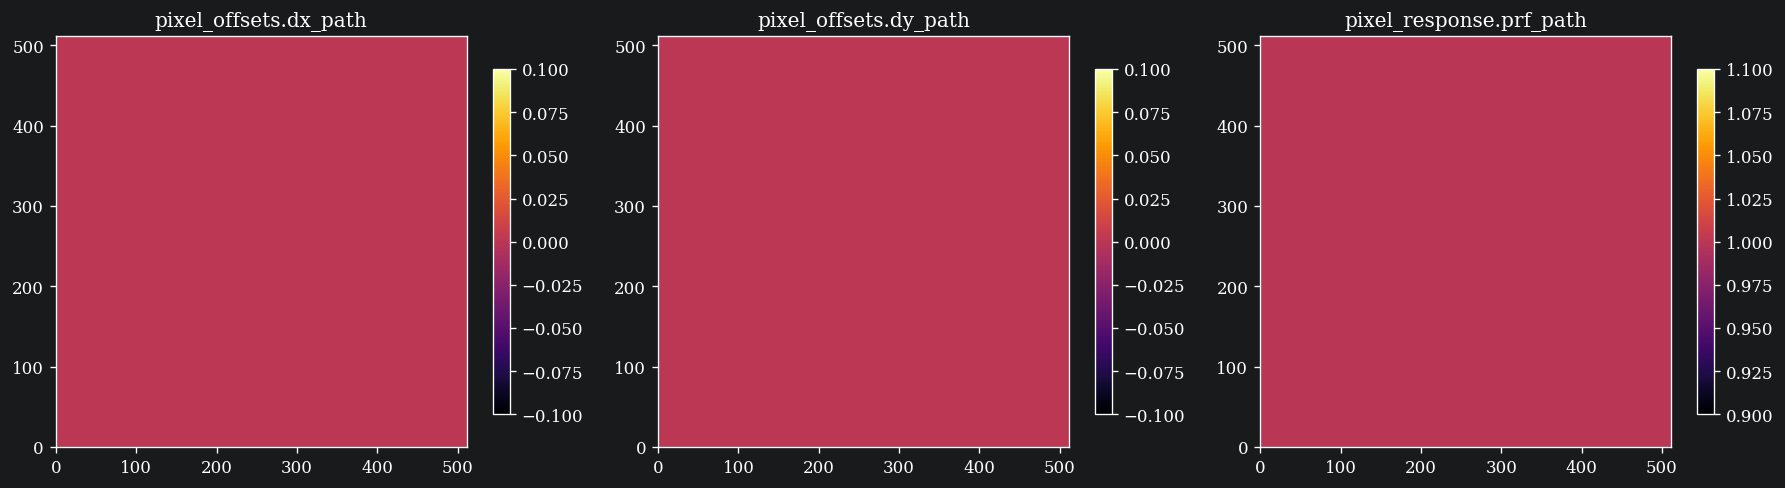

In [17]:
if cal_maps:
    n = len(cal_maps)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for ax, (name, arr) in zip(axes.flat, cal_maps.items()):
        im = ax.imshow(arr, origin="lower")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


## 7. Campaign noise-path audit

This section audits render/data noise separately from the inference likelihood variance model. It uses the resolved truth system rendered through the same Binder path as the full-fidelity campaign review, not an artificial spot image.


In [18]:
noise_summary = review.summarize_noise_config(translated, truth_system)
noise_render = None
if ENABLE_NOISE_AUDIT:
    noise_render = review.render_tiny_review_images(translated, truth_system, seed=123, crop_npix=64)
    noise_summary["variance_diagnostics"] = noise_render["variance_diagnostics"]
    noise_summary["render_noise"] = noise_render["render_noise"]
    noise_summary["warnings"] = list(noise_summary.get("warnings", [])) + list(noise_render.get("warnings", []))
print(json.dumps(noise_summary, indent=2, default=str))


FileNotFoundError: [Errno 2] No such file or directory: 'src/dluxshera/data/pupils/diffractive_pupil.npy'

In [ ]:
if noise_render is not None and noise_render.get("available"):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    panels = [
        ("noiseless", noise_render["noiseless"]),
        ("configured noisy", noise_render["configured_noisy"]),
        ("noise residual", noise_render["noise_residual"]),
        ("expected variance", noise_render["expected_variance"]),
    ]
    for ax, (title, image) in zip(axes[0], panels):
        im = ax.imshow(image, origin="lower")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, shrink=0.75)

    im = axes[1, 0].imshow(noise_render["normalized_residual"], origin="lower", vmin=-5, vmax=5)
    axes[1, 0].set_title("residual / sqrt(expected variance)")
    plt.colorbar(im, ax=axes[1, 0], shrink=0.75)
    axes[1, 1].hist(noise_render["noise_residual"].ravel(), bins=50)
    axes[1, 1].set_title("residual histogram")
    axes[1, 2].hist(noise_render["normalized_residual"].ravel(), bins=50, range=(-5, 5))
    axes[1, 2].set_title("normalized residual histogram")
    axes[1, 3].axis("off")
    rn = noise_summary["render_noise"]
    inf = noise_summary["inference_noise_model"]
    lines = [
        f"shot/read/dark: {rn['shot_noise']} / {rn['read_noise']} / {rn['dark_current']}",
        f"read noise: {rn['read_noise_electrons']} e- ({rn['read_noise_source']})",
        f"dark current: {rn['dark_current_e_per_s']} e-/s ({rn['dark_current_source']})",
        f"exposure: {rn['exposure_time_s']} s",
        f"inference variance: {inf['variance_model']}",
        f"variance floor: {inf['variance_floor']}",
    ]
    axes[1, 3].text(0.0, 1.0, "\n".join(lines), va="top", family="monospace")
    plt.tight_layout()
    plt.show()


## 8. Trajectory filtering review

This section reports the configured trajectory filter from `trace_source.processing.filter`. It distinguishes the campaign-used filter from the moving-average diagnostic shown for comparison.


In [ ]:
trajectory_review = review.load_trajectory_for_review(translated)
hp_review = review.make_high_pass_trajectory_diagnostic(trajectory_review, timescale_s=15.0)
filter_prov = trajectory_review.get("summary", {}).get("filter", {})
print(json.dumps(trajectory_review.get("summary", trajectory_review), indent=2, default=str))
print("configured filter enabled:", filter_prov.get("enabled", False))
print("configured filter kind:", filter_prov.get("kind"))
print("moving-average diagnostic note:", hp_review.get("note"))


In [ ]:
if trajectory_review.get("available"):
    traj = trajectory_review["trajectory"]
    raw_values = traj.unfiltered_values or traj.values
    fig, axes = plt.subplots(len(traj.values), 3, figsize=(16, 3.2 * len(traj.values)), squeeze=False)
    for row, key in enumerate(traj.values):
        t = traj.time_s
        raw = np.asarray(raw_values[key], dtype=float)
        filt = np.asarray(traj.values[key], dtype=float)
        removed = raw - filt
        axes[row, 0].plot(t, raw, lw=1, label="raw")
        axes[row, 0].plot(t, filt, lw=1, label="filtered")
        axes[row, 0].axvspan(trajectory_review["frame_times_s"][0], trajectory_review["frame_times_s"][-1], color="orange", alpha=0.18)
        axes[row, 0].set_title(f"raw vs filtered {key}")
        axes[row, 1].plot(t, removed, lw=1)
        axes[row, 1].set_title(f"removed component {key}")
        for block in trajectory_review["blocks"]:
            axes[row, 2].plot(block.frame_times_s, block.truth[key], marker="o", label="truth" if block.subblock_index == 0 else None)
            axes[row, 2].plot(block.frame_times_s, block.prediction[key], linestyle="--", label="linear fit" if block.subblock_index == 0 else None)
        axes[row, 2].set_title(f"selected segment and fit {key}")
        for ax in axes[row]:
            ax.grid(True, alpha=0.25)
    axes[0, 0].legend(loc="best")
    axes[0, 2].legend(loc="best")
    plt.tight_layout()
    plt.show()


In [ ]:
if trajectory_review.get("available"):
    traj = trajectory_review["trajectory"]
    rms_rows = []
    for key in traj.values:
        raw = np.asarray((traj.unfiltered_values or traj.values)[key], dtype=float)
        filt = np.asarray(traj.values[key], dtype=float)
        rms_rows.append({
            "column": key,
            "raw_rms": float(np.sqrt(np.mean(raw * raw))),
            "filtered_rms": float(np.sqrt(np.mean(filt * filt))),
            "removed_rms": float(np.sqrt(np.mean((raw - filt) ** 2))),
        })
    rms_df = pd.DataFrame(rms_rows)
    display(rms_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    rms_df.set_index("column")[["raw_rms", "filtered_rms", "removed_rms"]].plot(kind="bar", ax=ax)
    ax.set_title("trajectory RMS before/after configured filtering")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
if trajectory_review.get("available") and filter_prov.get("frequency_response"):
    response = filter_prov["frequency_response"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(response.get("frequency_hz", []), response.get("gain", []))
    ax.set_xlabel("frequency [Hz]")
    ax.set_ylabel("gain")
    ax.set_title("configured Bessel filter response")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

if trajectory_review.get("available"):
    traj = trajectory_review["trajectory"]
    dt = float(np.median(np.diff(traj.time_s)))
    fig, axes = plt.subplots(len(traj.values), 1, figsize=(11, 3 * len(traj.values)), squeeze=False)
    for ax, key in zip(axes[:, 0], traj.values):
        raw = np.asarray((traj.unfiltered_values or traj.values)[key], dtype=float)
        filt = np.asarray(traj.values[key], dtype=float)
        freq = np.fft.rfftfreq(raw.size, d=dt)
        ax.semilogy(freq[1:], np.abs(np.fft.rfft(raw - raw.mean()))[1:] ** 2, label="raw")
        ax.semilogy(freq[1:], np.abs(np.fft.rfft(filt - filt.mean()))[1:] ** 2, label="filtered")
        ax.set_title(f"FFT power {key}")
        ax.set_xlabel("frequency [Hz]")
        ax.grid(True, alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
if trajectory_review.get("available") and hp_review.get("available"):
    fig, axes = plt.subplots(len(hp_review["series"]), 1, figsize=(12, 3 * len(hp_review["series"])), squeeze=False)
    for ax, key in zip(axes[:, 0], hp_review["series"]):
        series = hp_review["series"][key]
        ax.plot(trajectory_review["trajectory"].time_s, series["raw"], label="raw", alpha=0.5)
        ax.plot(trajectory_review["trajectory"].time_s, series["low_pass"], label="15 s moving average")
        ax.plot(trajectory_review["trajectory"].time_s, series["high_pass"], label="diagnostic residual")
        ax.set_title(f"moving-average diagnostic {key}; residual RMS={series['rms_high_pass']:.4g}")
        ax.grid(True, alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 9. Trace jitter review

Explicit question: does `trace_jitter` add noise on top of the trajectory?


In [ ]:
trace_jitter_review = review.compare_trace_jitter_enabled_disabled(translated)
print(json.dumps(trace_jitter_review, indent=2, default=str))
display(pd.DataFrame([{"key": k, "rms_difference": v} for k, v in trace_jitter_review.get("rms_difference", {}).items()]))


## 10. Model rendering sanity checks

The campaign noise-path audit above performs the lightweight resolved-system Binder render used for sanity checks. This cell reports the render status without launching a campaign.


In [ ]:
render_review = {
    "available": bool(noise_render is not None and noise_render.get("available")),
    "source": None if noise_render is None else noise_render.get("source"),
    "variance_diagnostics": None if noise_render is None else noise_render.get("variance_diagnostics"),
}
print(json.dumps(render_review, indent=2, default=str))


## 11. Summary dashboard


In [ ]:
dashboard = pd.DataFrame(review.summary_dashboard(
    config=translated,
    base_cfg=base_system,
    truth_cfg=truth_system,
    inference_cfg=inference_system,
    model_split=split,
    trajectory_review=trajectory_review,
    trace_jitter_review=trace_jitter_review,
))
display(dashboard)


In [ ]:
if WRITE_ARTIFACTS:
    artifact_paths = review.write_review_artifacts(
        outdir,
        base_system_cfg=base_system,
        truth_system_cfg=truth_system,
        inference_system_cfg=inference_system,
        model_split=split,
        spectral_summary=spectral_summary,
        wfe_summary=wfe_summary,
        detector_summary=det_truth,
        noise_summary=noise_summary,
        trajectory_summary=trajectory_review.get("summary", trajectory_review),
    )
    print(json.dumps(artifact_paths, indent=2))


## Reviewer notes / decisions

- Source / spectral deck decision:
- WFE map decision:
- Detector / calibration decision:
- Noise decision:
- Trajectory / high-pass decision:
- Trace jitter decision:
- Config changes to make before campaign:
- Follow-up tasks:
